# Phase 2: Data Understanding

**CRISP-DM Phase Description:**  
This phase involves acquiring the data, getting familiar with it, identifying data quality problems, and detecting initial insights. A thorough understanding of the data at this stage is critical for a successful project.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
%matplotlib inline

In [11]:
df = pd.read_csv('../Train_data.csv')
print(df.head())

   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  num_failed_logins  logged_in  num_compromised  \
0               0       0    0                  0          0                0   
1               0       0    0                  0          0                0   
2               0       0    0                  0          0                0   
3               0       0    0                  0          1                0   
4               0       0    0                  0          1                0   

   root_shell  su_attempted  num_root  num_file_creations  num_shells  \
0      

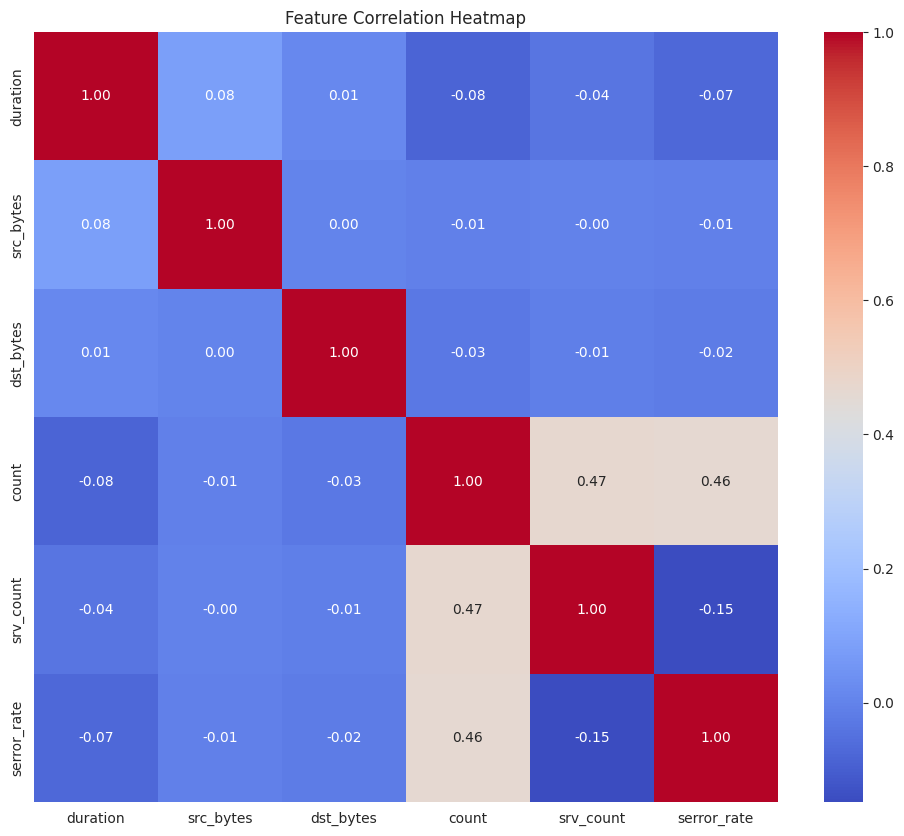

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

corr = df[['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count', 'serror_rate']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.savefig('correlation_heatmap.png') 
plt.show()

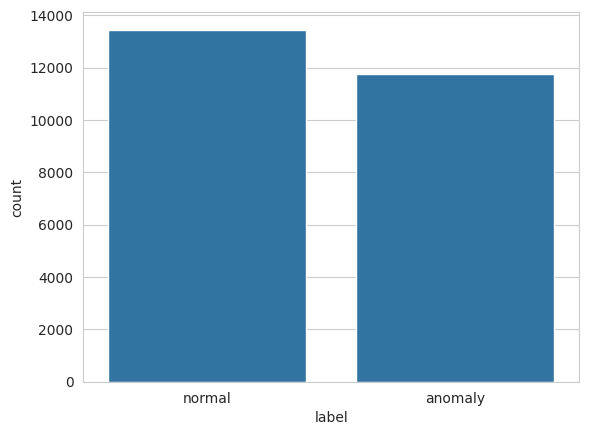

In [ ]:

df.columns = [*df.columns[:-1], 'label']
sns.countplot(x='label', data=df)
plt.show()

---
### Task 1: Collect Initial Data

Acquire the necessary data and load it into the analysis environment. This task includes:

- **Data Acquisition:** Load data from files, databases, APIs, or other sources.
- **Initial Data Report:** Document the data source(s), the method of acquisition, and any problems encountered during loading.

**Instructions:**
1. Update the file path(s) below to point to your actual dataset(s).
2. Load the data into a Pandas DataFrame.
3. Display a small sample of the data to confirm it loaded correctly.

In [ ]:
DATA_PATH = "Train_data.csv"

import pandas as pd

df = pd.read_csv(DATA_PATH)
df.head()

In [ ]:
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.sample(5)

In [ ]:
data_source_report = {
    "source": "Kaggle",
    "acquisition_method": "CSV download",
    "date_acquired": "2026",
    "issues_encountered": [
        "Possible class imbalance in intrusion vs normal data",
        "Some categorical features may require encoding",
        "Potential missing or noisy values"
    ]
}

print(data_source_report)

---
### Task 2: Describe Data

Examine the "surface" properties of the acquired data. This includes:

- **Volume:** How many records (rows) and attributes (columns) does the dataset contain?
- **Field Identities:** What are the names, data types, and roles (ID, feature, target) of each column?
- **Descriptive Statistics:** What are the basic statistics (mean, median, std, min, max) of the numerical features and frequency counts for categorical features?

**Instructions:** Use Pandas built-in methods (`.info()`, `.describe()`, `.dtypes`, `.value_counts()`) to generate a comprehensive description of your data.

In [ ]:
# TODO: Describe the structure and schema of your data.
# Inspect data types, non-null counts, and memory usage.

df.info()

In [ ]:
# Generate descriptive statistics for numerical columns
# df.describe()
df.describe()

In [ ]:
# Generate descriptive statistics for categorical columns
# df.describe(include='object')

# Or inspect value counts for specific categorical columns:
# for col in df.select_dtypes(include='object').columns:
#     print(f"\n--- {col} ---")
#     print(df[col].value_counts())
df.describe(include='object')
for col in df.select_dtypes(include='object').columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())

---
### Task 3: Explore Data

Dig deeper into the data using querying, visualisation, and statistical analysis to find initial insights, patterns, and interesting subsets. Key activities include:

- **Univariate Analysis:** Examine the distribution of individual features using histograms, box plots, and bar charts.
- **Bivariate / Multivariate Analysis:** Explore relationships between features using scatter plots, correlation matrices, and grouped summaries.
- **Initial Hypotheses:** Formulate initial hypotheses based on observed patterns.

**Instructions:** Create visualisations and run queries to understand the distributions, relationships, and patterns in your data.

In [ ]:
# TODO: Perform univariate analysis — explore distributions of individual features.
# Example: Histograms for numerical columns

df.hist(figsize=(14, 10), bins=30, edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# TODO: Perform bivariate/multivariate analysis — explore relationships between features.
# Example: Correlation heatmap

# plt.figure(figsize=(12, 8))
# correlation_matrix = df.select_dtypes(include=np.number).corr()
# sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
# plt.title('Correlation Matrix')
# plt.tight_layout()
# plt.show()
plt.figure(figsize=(12, 8))
correlation_matrix = df.select_dtypes(include=np.number).corr()

sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# TODO: Document any initial insights or hypotheses from your exploration.

initial_insights = [
    "Some numerical features show skewed distributions, indicating the presence of outliers in the dataset",
    
    "Certain features appear to have strong correlations with each other, suggesting possible redundancy or multicollinearity",
    
    "The dataset may be imbalanced, with significantly more normal traffic than attack instances",
    
    "Categorical features such as protocol type and service type show varying frequencies, which may influence classification performance",
    
    "Some features may not contribute significantly to the prediction and could be removed during feature selection",
    
    "Hypothesis: Features related to network traffic behavior (e.g., connection duration, number of bytes) are strong indicators of intrusion activity",
    
    "Hypothesis: Using ensemble models such as Random Forest will perform better than simpler models due to complex feature relationships"
]

for i, insight in enumerate(initial_insights, 1):
    print(f"{i}. {insight}")

---
### Task 4: Verify Data Quality

Evaluate the completeness and correctness of the data. Check for problems that could affect the analysis:

- **Missing Values:** Identify columns with missing data, the volume, and patterns of missingness.
- **Duplicates:** Check for and report duplicate records.
- **Outliers:** Detect anomalous values using statistical methods or visualisations (box plots, z-scores).
- **Inconsistencies:** Look for data type mismatches, inconsistent formatting, or invalid entries.

**Instructions:** Systematically check for data quality issues and document your findings.

In [ ]:
# TODO: Check for missing values.

# missing = df.isnull().sum()
# missing_pct = (df.isnull().sum() / len(df)) * 100
# missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
# missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)
# print("=== Missing Values Report ===")
# print(missing_report)
# print(f"\nTotal columns with missing values: {len(missing_report)}")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

missing_report = missing_report[missing_report['Missing Count'] > 0]\
                    .sort_values('Missing %', ascending=False)

print("=== Missing Values Report ===")
print(missing_report)

print(f"\nTotal columns with missing values: {len(missing_report)}")

In [ ]:
# TODO: Check for duplicate records.

# duplicates = df.duplicated().sum()
# print(f"Number of duplicate rows: {duplicates}")
# if duplicates > 0:
#     print("\nSample of duplicate rows:")
#     print(df[df.duplicated(keep=False)].head(10))
duplicates = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    print("\nSample of duplicate rows:")
    print(df[df.duplicated(keep=False)].head(10))

In [ ]:
# TODO: Detect outliers using box plots or statistical methods.

# numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# if numerical_cols:
#     fig, axes = plt.subplots(nrows=1, ncols=len(numerical_cols), figsize=(4 * len(numerical_cols), 5))
#     if len(numerical_cols) == 1:
#         axes = [axes]
#     for ax, col in zip(axes, numerical_cols):
#         ax.boxplot(df[col].dropna())
#         ax.set_title(col)
#     plt.suptitle('Box Plots — Outlier Detection', fontsize=14, y=1.02)
#     plt.tight_layout()
#     plt.show()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if numerical_cols:
    plt.figure(figsize=(15, 8))
    
    df[numerical_cols].boxplot(rot=90)
    
    plt.title('Box Plots — Outlier Detection')
    plt.tight_layout()
    plt.show()